<a href="https://colab.research.google.com/github/firstsignal/activation-geometry-sentiment/blob/main/activation_space_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip -q install transformer-lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.1 MB/s eta 0:00:00


In [3]:
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained('pythia-70m')

print('Model loaded!')

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Loaded pretrained model pythia-70m into HookedTransformer
Model loaded!


In [4]:
import torch

# Small labelled set. Keep sentences short and clearly polarised for v1.
positive = [
    "I love this, it is wonderful and makes me so happy.",
    "This is fantastic, absolutely delightful and brilliant.",
    "What a joyful, beautiful, amazing day this has been.",
    "I feel great, everything is going perfectly and I am thrilled.",
    "That was excellent, truly the best experience of my life.",
]
negative = [
    "I hate this, it is awful and makes me so miserable.",
    "This is terrible, absolutely disgusting and dreadful.",
    "What a bleak, ugly, horrible day this has been.",
    "I feel awful, everything is going wrong and I am furious.",
    "That was dreadful, truly the worst experience of my life.",
]

LAYER = 3  # a middle-ish layer for a 6-layer model; we can sweep later

def get_resid(prompts):
    vecs = []
    for p in prompts:
        tokens = model.to_tokens(p)
        _, cache = model.run_with_cache(tokens)
        # residual stream at LAYER, mean over sequence positions
        act = cache["resid_post", LAYER][0].mean(dim=0)
        vecs.append(act)
    return torch.stack(vecs)

pos_acts = get_resid(positive)
neg_acts = get_resid(negative)

print("pos_acts shape:", pos_acts.shape)
print("neg_acts shape:", neg_acts.shape)


pos_acts shape: torch.Size([5, 512])
neg_acts shape: torch.Size([5, 512])


In [5]:
# Difference-of-means: the sentiment axis
pos_mean = pos_acts.mean(dim=0)
neg_mean = neg_acts.mean(dim=0)
sentiment_dir = pos_mean - neg_mean
sentiment_dir = sentiment_dir / sentiment_dir.norm()  # unit vector

# Project every training sentence onto the axis
def project(acts, direction):
    return acts @ direction

pos_proj = project(pos_acts, sentiment_dir)
neg_proj = project(neg_acts, sentiment_dir)

print("positive projections:", [round(x.item(), 2) for x in pos_proj])
print("negative projections:", [round(x.item(), 2) for x in neg_proj])

# --- CONTROL: a random direction should NOT separate them ---
torch.manual_seed(0)
random_dir = torch.randn(512)
random_dir = random_dir / random_dir.norm()

pos_ctrl = project(pos_acts, random_dir)
neg_ctrl = project(neg_acts, random_dir)

print("\n--- control (random direction) ---")
print("positive:", [round(x.item(), 2) for x in pos_ctrl])
print("negative:", [round(x.item(), 2) for x in neg_ctrl])


positive projections: [-1.84, -2.0, -2.06, -2.15, -1.77]
negative projections: [-4.16, -4.84, -4.46, -4.14, -4.43]

--- control (random direction) ---
positive: [0.14, 0.2, 0.39, 0.15, 0.3]
negative: [0.24, 0.33, 0.64, 0.15, 0.42]


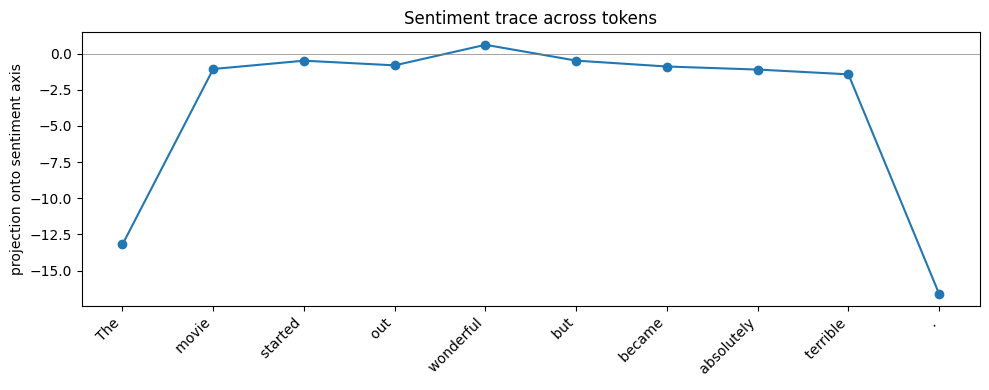

In [6]:
import matplotlib.pyplot as plt

test_sentence = "The movie started out wonderful but became absolutely terrible."

tokens = model.to_tokens(test_sentence)
_, cache = model.run_with_cache(tokens)
resid = cache["resid_post", LAYER][0]          # [seq, 512]
trace = resid @ sentiment_dir                   # project each token

str_tokens = model.to_str_tokens(test_sentence)

plt.figure(figsize=(10, 4))
plt.plot(range(len(trace)), trace.detach().numpy(), marker="o")
plt.xticks(range(len(str_tokens)), str_tokens, rotation=45, ha="right")
plt.axhline(0, color="gray", linewidth=0.5)
plt.ylabel("projection onto sentiment axis")
plt.title("Sentiment trace across tokens")
plt.tight_layout()
plt.show()


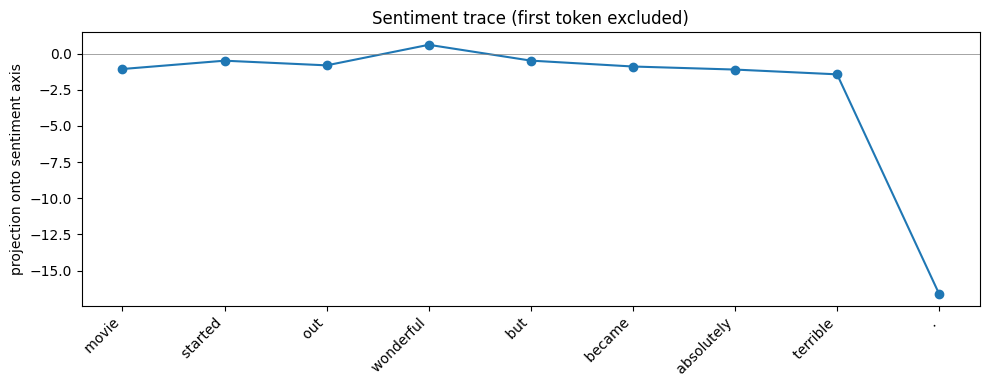

In [7]:
# Re-plot excluding the first (BOS/sink) token, which dominates the scale
import matplotlib.pyplot as plt

trace_np = trace.detach().numpy()
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(trace_np)), trace_np[1:], marker="o")
plt.xticks(range(1, len(str_tokens)), str_tokens[1:], rotation=45, ha="right")
plt.axhline(0, color="gray", linewidth=0.5)
plt.ylabel("projection onto sentiment axis")
plt.title("Sentiment trace (first token excluded)")
plt.tight_layout()
plt.show()


Zooming in: decomposing each token’s update into movement along the sentiment axis versus off-axis

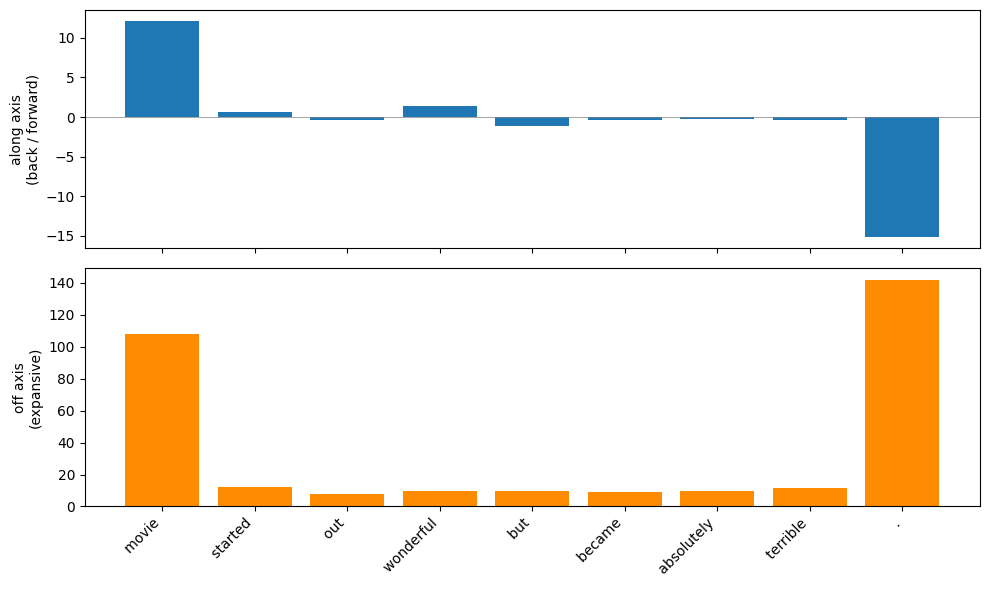

In [8]:
import torch
import matplotlib.pyplot as plt

sentence = "The movie started out wonderful but became absolutely terrible."
tokens = model.to_tokens(sentence)
_, cache = model.run_with_cache(tokens)
resid = cache["resid_post", LAYER][0]            # [seq, 512]
str_toks = model.to_str_tokens(sentence)

# Per-token update vectors: what each word DID to the state
delta = resid[1:] - resid[:-1]                   # [seq-1, 512]

# Decompose each update: along sentiment axis vs perpendicular
parallel = delta @ sentiment_dir                 # signed: back(-) / forward(+)
para_vec = parallel[:, None] * sentiment_dir[None, :]
perp = (delta - para_vec).norm(dim=-1)           # expansive: off-axis movement

labels = str_toks[1:]                            # word that caused each update

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].bar(range(len(parallel)), parallel.detach().numpy())
ax[0].axhline(0, color="gray", lw=0.5)
ax[0].set_ylabel("along axis\n(back / forward)")
ax[1].bar(range(len(perp)), perp.detach().numpy(), color="darkorange")
ax[1].set_ylabel("off axis\n(expansive)")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.tight_layout()
plt.show()


Orientation view: each update as an angle to the axis, a magnitude, and a turn relative to the previous update.

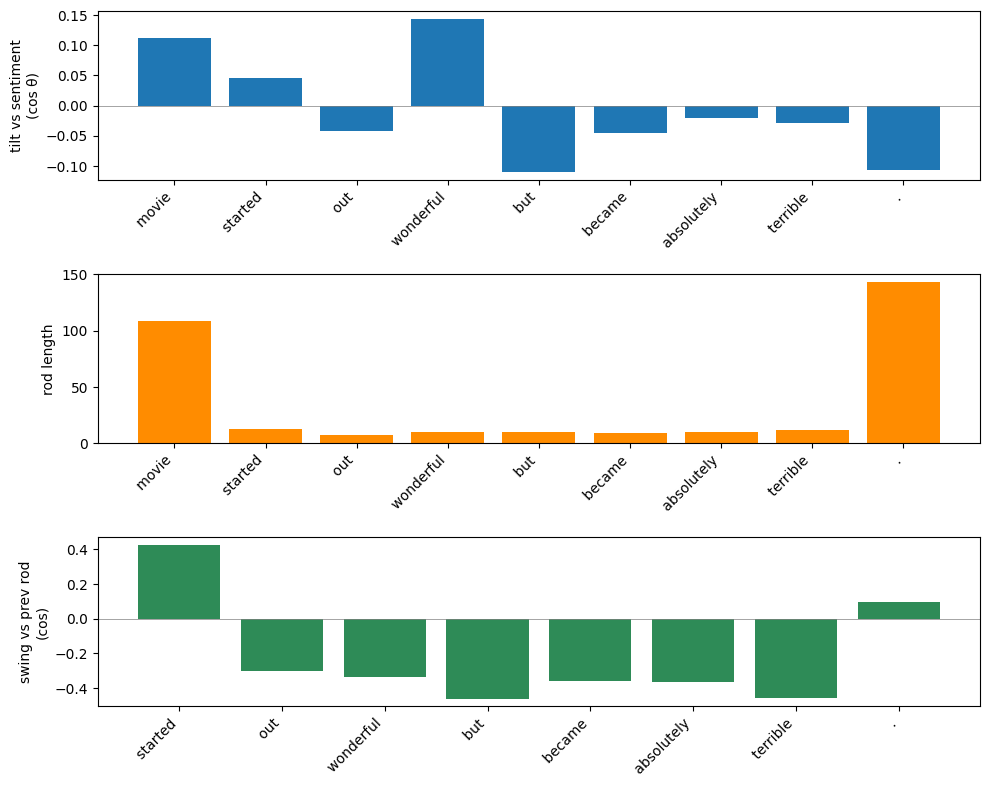

In [9]:
import torch, matplotlib.pyplot as plt

sentence = "The movie started out wonderful but became absolutely terrible."
tokens = model.to_tokens(sentence)
_, cache = model.run_with_cache(tokens)
resid = cache["resid_post", LAYER][0]
str_toks = model.to_str_tokens(sentence)

delta = resid[1:] - resid[:-1]
labels = str_toks[1:]

# Rod tilt vs sentiment axis (angle), and rod length (magnitude)
tilt = (delta @ sentiment_dir) / delta.norm(dim=-1)      # cos θ, in [-1, 1]
length = delta.norm(dim=-1)

# Rod-to-rod swing: does each word continue or turn the trajectory?
swing = torch.nn.functional.cosine_similarity(delta[1:], delta[:-1], dim=-1)

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
ax[0].bar(range(len(tilt)), tilt.detach().numpy()); ax[0].axhline(0, c="gray", lw=.5)
ax[0].set_ylabel("tilt vs sentiment\n(cos θ)"); ax[0].set_xticks(range(len(labels))); ax[0].set_xticklabels(labels, rotation=45, ha="right")
ax[1].bar(range(len(length)), length.detach().numpy(), color="darkorange")
ax[1].set_ylabel("rod length"); ax[1].set_xticks(range(len(labels))); ax[1].set_xticklabels(labels, rotation=45, ha="right")
ax[2].bar(range(len(swing)), swing.detach().numpy(), color="seagreen"); ax[2].axhline(0, c="gray", lw=.5)
ax[2].set_ylabel("swing vs prev rod\n(cos)"); ax[2].set_xticks(range(len(swing))); ax[2].set_xticklabels(labels[1:], rotation=45, ha="right")
plt.tight_layout(); plt.show()


Rod view: each token’s update drawn from the reference point — angle = tilt toward/away from the sentiment axis, length = magnitude of the shift. Endpoint tokens excluded as positional artifacts. The same rods are plotted against a random axis as a control: structure should appear only on the left.

## Orientation view: token updates as rods

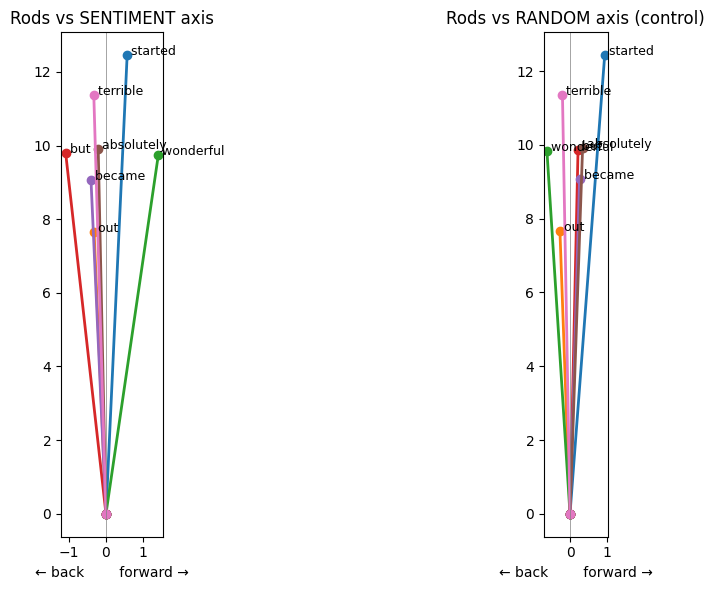

In [10]:
import torch, numpy as np, matplotlib.pyplot as plt

sentence = "The movie started out wonderful but became absolutely terrible."
tokens = model.to_tokens(sentence)
_, cache = model.run_with_cache(tokens)
resid = cache["resid_post", LAYER][0]
str_toks = model.to_str_tokens(sentence)

delta = resid[1:] - resid[:-1]
labels = str_toks[1:]

# exclude the two contaminated endpoints: first content delta and final period
delta_mid = delta[1:-1]
labels_mid = labels[1:-1]

torch.manual_seed(0)
random_dir = torch.randn(512); random_dir = random_dir / random_dir.norm()

def rod_scope(ax, direction, title):
    tilt = (delta_mid @ direction) / delta_mid.norm(dim=-1)   # cos θ in [-1,1]
    length = delta_mid.norm(dim=-1)
    angles = np.arccos(tilt.detach().numpy().clip(-1, 1))     # 0=aligned, pi=anti
    for ang, L, lab in zip(angles, length.detach().numpy(), labels_mid):
        ax.plot([0, np.cos(ang)*L], [0, np.sin(ang)*L], marker="o", lw=2)
        ax.annotate(lab, (np.cos(ang)*L, np.sin(ang)*L), fontsize=9)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_title(title)
    ax.set_xlabel("← back        forward →")
    ax.set_aspect("equal")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
rod_scope(axes[0], sentiment_dir, "Rods vs SENTIMENT axis")
rod_scope(axes[1], random_dir, "Rods vs RANDOM axis (control)")
plt.tight_layout(); plt.show()


In [11]:
import numpy as np, torch
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

sentence = "The movie started out wonderful but became absolutely terrible."
tokens = model.to_tokens(sentence)
_, cache = model.run_with_cache(tokens)
resid = cache["resid_post", LAYER][0]
str_toks = model.to_str_tokens(sentence)

delta = resid[1:] - resid[:-1]
labels = str_toks[1:]
delta_mid = delta[1:-1]            # drop contaminated endpoints
labels_mid = labels[1:-1]

tilt = (delta_mid @ sentiment_dir) / delta_mid.norm(dim=-1)
angles = np.arccos(tilt.detach().numpy().clip(-1, 1))   # 0 = forward, pi = back
lengths = delta_mid.norm(dim=-1).detach().numpy()
lengths = lengths / lengths.max()                        # normalize rod to <=1

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
ax.plot(0, 0, "ko", markersize=8)                        # the dot
rod, = ax.plot([], [], lw=3, color="crimson")
label = ax.text(0, 1.1, "", ha="center", fontsize=14)
ax.set_xlabel("← back        forward →")
ax.set_title("Rod scope: one update at a time")

def update(i):
    a, L = angles[i], lengths[i]
    x, y = np.cos(a) * L, np.sin(a) * L
    rod.set_data([-x, x], [-y, y])                       # rod centered on the dot
    label.set_text(labels_mid[i])
    return rod, label

anim = animation.FuncAnimation(fig, update, frames=len(labels_mid), interval=900)
plt.close(fig)
HTML(anim.to_jshtml())



In [12]:
import numpy as np, torch
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

sentence = "The movie started out wonderful but became absolutely terrible."
tokens = model.to_tokens(sentence)
_, cache = model.run_with_cache(tokens)
resid = cache["resid_post", LAYER][0]
str_toks = model.to_str_tokens(sentence)

delta = resid[1:] - resid[:-1]
labels = str_toks[1:]
delta_mid = delta[1:-1]
labels_mid = labels[1:-1]

tilt = (delta_mid @ sentiment_dir) / delta_mid.norm(dim=-1)
tilts_np = tilt.detach().numpy().clip(-1, 1)
lengths = delta_mid.norm(dim=-1).detach().numpy()
lengths = lengths / lengths.max()

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
ax.plot(0, 0, "ko", markersize=8)
rod, = ax.plot([], [], lw=3, color="crimson")
label = ax.text(0, 1.1, "", ha="center", fontsize=14)
ax.set_xlabel("flat = neutral   |   right tip up = forward, down = back")
ax.set_title("Rod scope: needle view, one update at a time")

def update(i):
    deflect = tilts_np[i] * (np.pi / 2)   # sentiment tilt -> needle swing
    L = lengths[i]
    x, y = np.cos(deflect) * L, np.sin(deflect) * L
    rod.set_data([-x, x], [-y, y])
    label.set_text(labels_mid[i])
    return rod, label

anim = animation.FuncAnimation(fig, update, frames=len(labels_mid), interval=900)
plt.close(fig)
HTML(anim.to_jshtml())


First version: rod angle mapped directly from cos θ (vertical = neutral). Superseded by the needle view below (flat = neutral).

## Finding: the pivot carries the turn

Testing each token's update against the sentiment axis produced an unexpected result. The prediction was that "terrible" — the negative content word — would show the strongest backward tilt. It didn't. The strongest backward tilt falls on "but".

The model's internal state turns negative at the discourse pivot, before any negative word has arrived. "But" is where the sentence announces its reversal, and the geometry shows the model acting on that announcement immediately — the connective does the semantic work, and "terrible" then lands in a state already turned.

In imaging terms: the contrast change appears at the boundary marker, not at the structure itself.

Caveats, stated plainly: this is one sentence (n=1), one small model (Pythia-70m), one layer. Whether the pivot consistently out-tilts the content word across sentences, models, and layers is untested. The observation earns a follow-up experiment, not a claim.


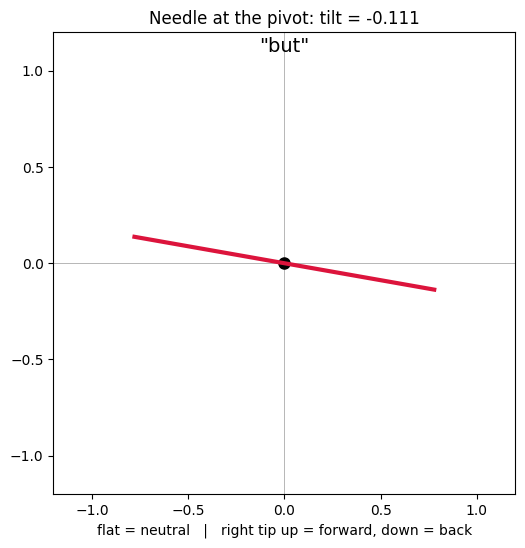

In [13]:
import numpy as np
import matplotlib.pyplot as plt

WORD = "but"   # change to any token in labels_mid, e.g. "wonderful"

i = [w.strip() for w in labels_mid].index(WORD)
deflect = tilts_np[i] * (np.pi / 2)
L = lengths[i]
x, y = np.cos(deflect) * L, np.sin(deflect) * L

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
ax.plot(0, 0, "ko", markersize=8)
ax.plot([-x, x], [-y, y], lw=3, color="crimson")
ax.text(0, 1.1, f'"{labels_mid[i].strip()}"', ha="center", fontsize=14)
ax.set_xlabel("flat = neutral   |   right tip up = forward, down = back")
ax.set_title(f"Needle at the pivot: tilt = {tilts_np[i]:.3f}")
plt.show()


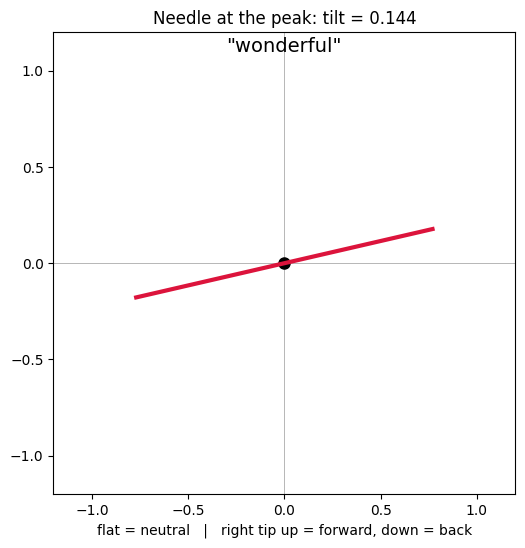

In [14]:
import numpy as np
import matplotlib.pyplot as plt

WORD = "wonderful"

i = [w.strip() for w in labels_mid].index(WORD)
deflect = tilts_np[i] * (np.pi / 2)
L = lengths[i]
x, y = np.cos(deflect) * L, np.sin(deflect) * L

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
ax.plot(0, 0, "ko", markersize=8)
ax.plot([-x, x], [-y, y], lw=3, color="crimson")
ax.text(0, 1.1, f'"{labels_mid[i].strip()}"', ha="center", fontsize=14)
ax.set_xlabel("flat = neutral   |   right tip up = forward, down = back")
ax.set_title(f"Needle at the peak: tilt = {tilts_np[i]:.3f}")
plt.show()


## Chapter 2: Two axes, one state

Building a second feature direction — tense — with the identical recipe as sentiment: difference-of-means, same layer, validated against a random control. The question this chapter tests: how does one state hold two readable meanings without corrupting either?


In [15]:
import torch

past = [
    "She walked to the station and caught the early train.",
    "They finished the project and celebrated last night.",
    "He wrote the letter and posted it yesterday morning.",
    "We visited the museum and admired the old paintings.",
    "I cooked dinner and washed the dishes afterwards.",
]
present = [
    "She walks to the station and catches the early train.",
    "They finish the project and celebrate tonight.",
    "He writes the letter and posts it this morning.",
    "We visit the museum and admire the old paintings.",
    "I cook dinner and wash the dishes afterwards.",
]

past_acts = get_resid(past)        # reuses your function from chapter 1
pres_acts = get_resid(present)

tense_dir = past_acts.mean(dim=0) - pres_acts.mean(dim=0)
tense_dir = tense_dir / tense_dir.norm()

# Validate: same discipline as sentiment
past_proj = past_acts @ tense_dir
pres_proj = pres_acts @ tense_dir
print("past projections:   ", [round(x.item(), 2) for x in past_proj])
print("present projections:", [round(x.item(), 2) for x in pres_proj])

torch.manual_seed(1)               # different seed from chapter 1's control
rand2 = torch.randn(512); rand2 = rand2 / rand2.norm()
print("\n--- control (random direction) ---")
print("past:   ", [round(x.item(), 2) for x in (past_acts @ rand2)])
print("present:", [round(x.item(), 2) for x in (pres_acts @ rand2)])

# THE number — your side-by-side prediction on trial
cos = (sentiment_dir @ tense_dir).item()
print(f"\ncosine(sentiment axis, tense axis) = {cos:.4f}")


past projections:    [-13.43, -16.24, -13.14, -15.99, -16.46]
present projections: [-14.48, -19.18, -14.79, -16.88, -17.63]

--- control (random direction) ---
past:    [2.25, 2.74, 2.28, 2.89, 2.75]
present: [2.4, 3.09, 2.4, 2.85, 2.66]

cosine(sentiment axis, tense axis) = -0.0373


In [16]:
for L in range(6):
    def resid_at(prompts, layer):
        vecs = []
        for p in prompts:
            _, c = model.run_with_cache(model.to_tokens(p))
            vecs.append(c["resid_post", layer][0].mean(dim=0))
        return torch.stack(vecs)
    pa, pr = resid_at(past, L), resid_at(present, L)
    d = pa.mean(0) - pr.mean(0); d = d / d.norm()
    gap = (pa @ d).min().item() - (pr @ d).max().item()
    print(f"layer {L}: worst-case gap = {gap:.2f}  {'SEPARATES' if gap > 0 else 'overlaps'}")


layer 0: worst-case gap = 0.28  SEPARATES
layer 1: worst-case gap = 0.07  SEPARATES
layer 2: worst-case gap = -1.86  overlaps
layer 3: worst-case gap = -1.98  overlaps
layer 4: worst-case gap = -0.29  overlaps
layer 5: worst-case gap = -3.03  overlaps


In [17]:
TENSE_LAYER = 0

def resid_at(prompts, layer):
    vecs = []
    for p in prompts:
        _, c = model.run_with_cache(model.to_tokens(p))
        vecs.append(c["resid_post", layer][0].mean(dim=0))
    return torch.stack(vecs)

past0, pres0 = resid_at(past, TENSE_LAYER), resid_at(present, TENSE_LAYER)
tense_dir0 = past0.mean(0) - pres0.mean(0)
tense_dir0 = tense_dir0 / tense_dir0.norm()

print("past:   ", [round(x.item(), 2) for x in (past0 @ tense_dir0)])
print("present:", [round(x.item(), 2) for x in (pres0 @ tense_dir0)])

torch.manual_seed(2)
r = torch.randn(512); r = r / r.norm()
print("\ncontrol past:   ", [round(x.item(), 2) for x in (past0 @ r)])
print("control present:", [round(x.item(), 2) for x in (pres0 @ r)])

# sentiment axis rebuilt at the SAME layer for a fair cosine
posl0, negl0 = resid_at(positive, TENSE_LAYER), resid_at(negative, TENSE_LAYER)
sent_dir0 = posl0.mean(0) - negl0.mean(0); sent_dir0 = sent_dir0 / sent_dir0.norm()
print(f"\ncosine(sentiment, tense) at layer {TENSE_LAYER} = {(sent_dir0 @ tense_dir0).item():.4f}")


past:    [0.02, 0.09, 0.23, -0.27, -0.12]
present: [-0.55, -0.96, -0.7, -0.85, -0.9]

control past:    [0.65, 0.57, 0.54, 0.55, 0.64]
control present: [0.68, 0.57, 0.57, 0.49, 0.56]

cosine(sentiment, tense) at layer 0 = -0.0618


The tense axis failed validation at layer 3: clusters overlapped under mean-pooling, likely dilution since tense occupies only a few tokens per sentence. A layer sweep located separation only at layers 0–1 — tense lives at the surface, where token identity is fresh, while sentiment peaks mid-network. Rebuilt at layer 0, the axis validates (no overlap; random control shows none). Cosine between sentiment and tense axes in the same space: −0.06 — the two features are held nearly orthogonally, consistent with the side-by-side prediction. Caveat: the layer-0 axis may partly detect verb-form vocabulary rather than abstract tense; and features evidently stagger across depth, which the next experiment must respect.

## Experiment 5: the assembly ladder

Hypothesis (from intuition, formalised): the layer where a feature lives is set by its assembly distance — how far the meaning sits from the literal tokens. Meanings spelled in the letters (tense, plurality) should resolve at the surface; meanings that exist only in relations between words (sentiment) should live deeper. Prediction, locked: best-separating layer climbs in the order plurality ≈ tense < sentiment.


In [18]:
import torch

def resid_at(prompts, layer):
    vecs = []
    for p in prompts:
        _, c = model.run_with_cache(model.to_tokens(p))
        vecs.append(c["resid_post", layer][0].mean(dim=0))
    return torch.stack(vecs)

def best_layer(setA, setB, name):
    print(f"\n{name}:")
    for L in range(6):
        a, b = resid_at(setA, L), resid_at(setB, L)
        d = a.mean(0) - b.mean(0); d = d / d.norm()
        gap = (a @ d).min().item() - (b @ d).max().item()
        print(f"  layer {L}: gap = {gap:.2f}  {'SEPARATES' if gap > 0 else 'overlaps'}")

# Rung 1: plurality — in the letters, matched pairs
singular = [
    "The dog runs across the field near the river.",
    "A child plays in the garden every afternoon.",
    "The teacher explains the lesson to the class.",
    "The bird sings loudly from the tall tree.",
    "The car waits outside the old station.",
]
plural = [
    "The dogs run across the fields near the rivers.",
    "Children play in the gardens every afternoon.",
    "The teachers explain the lessons to the classes.",
    "The birds sing loudly from the tall trees.",
    "The cars wait outside the old stations.",
]

best_layer(singular, plural, "PLURALITY (surface — in the letters)")
best_layer(past, present, "TENSE (surface — in the letters)")
best_layer(positive, negative, "SENTIMENT (relational — between the words)")



PLURALITY (surface — in the letters):
  layer 0: gap = 0.23  SEPARATES
  layer 1: gap = 0.41  SEPARATES
  layer 2: gap = -3.93  overlaps
  layer 3: gap = -3.87  overlaps
  layer 4: gap = 0.61  SEPARATES
  layer 5: gap = -1.12  overlaps

TENSE (surface — in the letters):
  layer 0: gap = 0.28  SEPARATES
  layer 1: gap = 0.07  SEPARATES
  layer 2: gap = -1.86  overlaps
  layer 3: gap = -1.98  overlaps
  layer 4: gap = -0.29  overlaps
  layer 5: gap = -3.03  overlaps

SENTIMENT (relational — between the words):
  layer 0: gap = 0.47  SEPARATES
  layer 1: gap = 1.12  SEPARATES
  layer 2: gap = 1.49  SEPARATES
  layer 3: gap = 2.00  SEPARATES
  layer 4: gap = 2.82  SEPARATES
  layer 5: gap = 3.67  SEPARATES


Assembly-distance prediction largely confirmed with refinement: surface features (tense, plurality) separate only at layers 0–1 and decay; sentiment separates at every layer and grows monotonically to layer 5. Refined claim: lexical meanings fade with depth, relational meanings accumulate. Caveats: sentiment set is not vocabulary-matched (layer-0 separation partly lexical); plurality’s layer-4 reappearance unexplained; n=5 throughout.